1. Постройте график по данным из station_stat_full, где для каждой АЗС будет отдельная точка: 

по горизонтальной оси — число заездов на АЗС, по вертикальной — медианное время заправки. Добавьте линии сетки.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

In [5]:
data = pd.read_csv("./visits.csv", sep="\t")
data['date_time'] = pd.to_datetime(data['date_time'], format='%Y%m%dT%H%M%S') + pd.Timedelta(hours=3)

In [8]:
data['local_time'] = (pd.to_datetime(data['date_time'], format='%Y-%m-%dT%H:%M:%S')
    + pd.Timedelta(hours=3))

data['date_hour'] = data['local_time'].dt.round('1H')

data['too_fast'] = data['time_spent'] < 60

data['too_slow'] = data['time_spent'] > 1000

too_fast_stat = data.pivot_table(index="id", values="too_fast")

C:\Users\yuliy\AppData\Local\Temp\ipykernel_22536\2172970547.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['date_hour'] = data['local_time'].dt.round('1H')


In [9]:
good_ids = too_fast_stat.query('too_fast < 0.5')

good_data = data.query('id in @good_ids.index')

good_data = good_data.query('60 <= time_spent <= 1000')

In [12]:
station_stat = data.pivot_table(index="id", values="time_spent", aggfunc="median")
good_station_stat = good_data.pivot_table(index="id", values="time_spent", aggfunc="median")

In [14]:
id_name = good_data.pivot_table(index='id', values='name', aggfunc=['first', 'count'])
id_name.columns = ['name', 'count']
station_stat_full = id_name.join(good_station_stat)


In [15]:
good_stat2 = (station_stat_full.query('count > 30').pivot_table(index='name', values='time_spent', aggfunc=['median', 'count']))
good_stat2.columns = ['median_time', 'stations']
final_stat = stat.join(good_stat2)

<Axes: xlabel='count', ylabel='time_spent'>

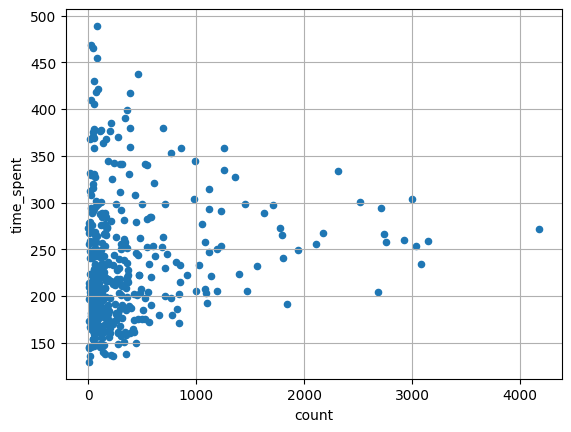

In [16]:
station_stat_full.plot(x='count', y='time_spent', kind='scatter', grid=True) 

2. По данным из таблицы station_stat_full посчитайте коэффициент корреляции Пирсона между числом заездов на АЗС и временем заправки. Коэффициент выведите на экран.

In [18]:
print(station_stat_full['count'].corr(station_stat_full['time_spent']))

0.12242632473597156


3. Создайте переменную station_stat_multi, где для каждой АЗС будет 3 числа:

среднее время (не медиана) заезда на АЗС;

средняя доля быстрых заездов;

средняя доля медленных заездов.

Затем выведите на экран матрицу корреляции между этими величинами. Постройте диаграмму рассеяния попарно для всех величин методом scatter_matrix. Задайте размер 9х9 дюймов.

In [20]:
stat = data.pivot_table(index='name', values='time_spent')
good_stat = good_data.pivot_table(index='name', values='time_spent', aggfunc='median')
stat['good_time_spent'] = good_stat['time_spent']

name_stat = data.pivot_table(index='name', values='time_spent')
good_name_stat = good_data.pivot_table(index='name', values='time_spent', aggfunc='median')
name_stat['good_time_spent'] = good_name_stat['time_spent']

id_name = good_data.pivot_table(index='id', values='name', aggfunc=['first', 'count'])
id_name.columns = ['name', 'count']

In [21]:
station_stat_multi = good_data.pivot_table(index='name', values=['time_spent', 'too_fast', 'too_slow'], aggfunc='mean')

In [24]:
station_stat_multi.corr()

,time_spent,too_fast,too_slow
time_spent,1.0,NaN,NaN
too_fast,NaN,NaN,NaN
too_slow,NaN,NaN,NaN


C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


array([[<Axes: xlabel='time_spent', ylabel='time_spent'>,
        <Axes: xlabel='too_fast', ylabel='time_spent'>,
        <Axes: xlabel='too_slow', ylabel='time_spent'>],
       [<Axes: xlabel='time_spent', ylabel='too_fast'>,
        <Axes: xlabel='too_fast', ylabel='too_fast'>,
        <Axes: xlabel='too_slow', ylabel='too_fast'>],
       [<Axes: xlabel='time_spent', ylabel='too_slow'>,
        <Axes: xlabel='too_fast', ylabel='too_slow'>,
        <Axes: xlabel='too_slow', ylabel='too_slow'>]], dtype=object)

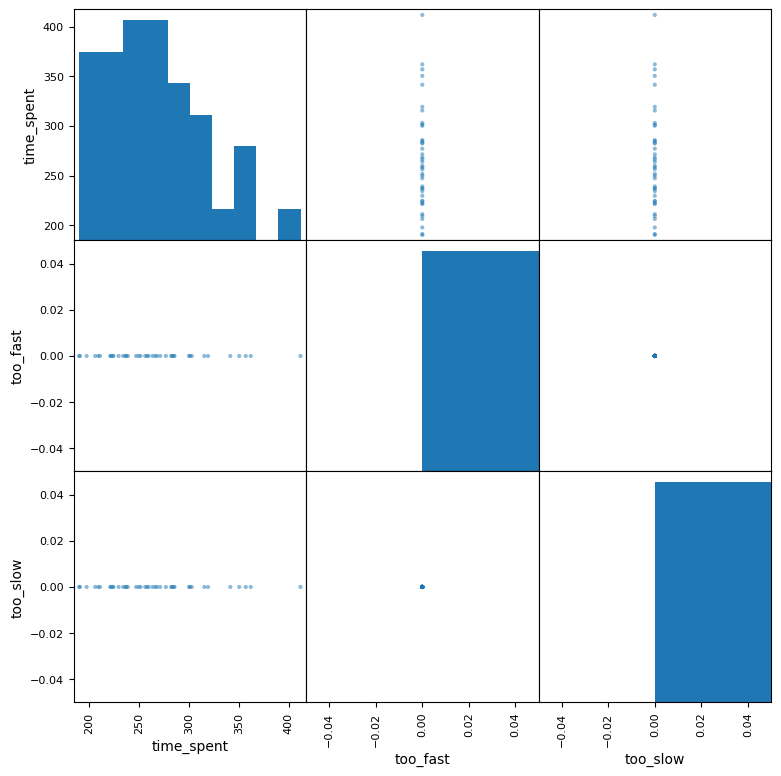

In [23]:
pd.plotting.scatter_matrix(station_stat_multi, figsize=(9, 9)) 

C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


array([[<Axes: xlabel='time_spent', ylabel='time_spent'>,
        <Axes: xlabel='too_fast', ylabel='time_spent'>,
        <Axes: xlabel='too_slow', ylabel='time_spent'>],
       [<Axes: xlabel='time_spent', ylabel='too_fast'>,
        <Axes: xlabel='too_fast', ylabel='too_fast'>,
        <Axes: xlabel='too_slow', ylabel='too_fast'>],
       [<Axes: xlabel='time_spent', ylabel='too_slow'>,
        <Axes: xlabel='too_fast', ylabel='too_slow'>,
        <Axes: xlabel='too_slow', ylabel='too_slow'>]], dtype=object)

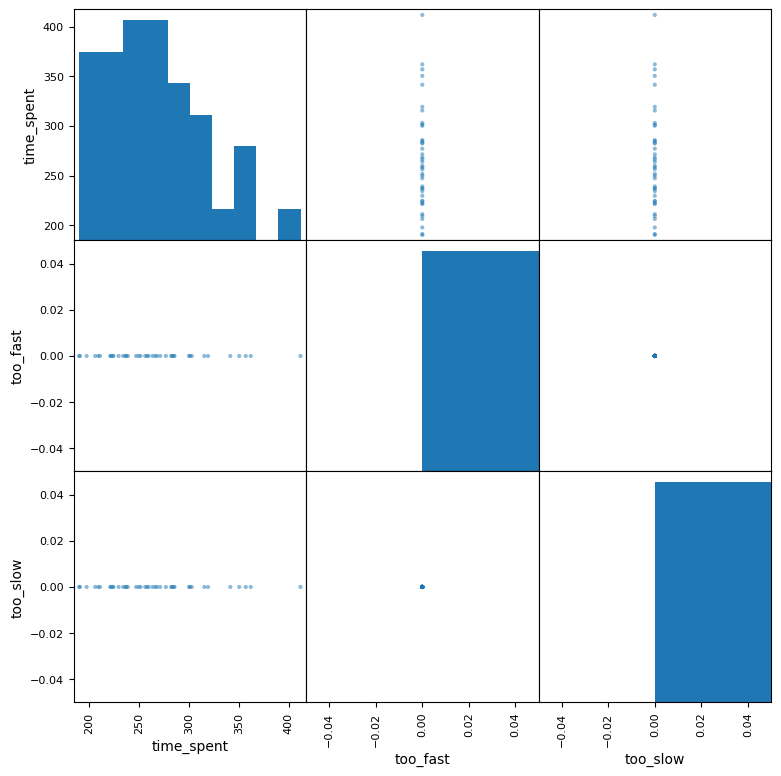

In [22]:
pd.plotting.scatter_matrix(station_stat_multi, figsize=(9, 9))

4. Добавьте в таблицу station_stat_multi столбец 'good_time_spent' из данных good_station_stat.

Распечатайте матрицу корреляции для station_stat_multi. Постройте диаграммы рассеяния попарно для всех величин методом scatter_matrix. Задайте размер 9х9 дюймов.

In [31]:
station_stat_multi['good_time_spent'] = good_station_stat['time_spent']


In [32]:
print(station_stat_multi.corr())


                 time_spent  too_fast  too_slow  good_time_spent
time_spent              1.0       NaN       NaN              NaN
too_fast                NaN       NaN       NaN              NaN
too_slow                NaN       NaN       NaN              NaN
good_time_spent         NaN       NaN       NaN              NaN


In [34]:
print(station_stat_multi.isnull().sum())


time_spent          0
too_fast            0
too_slow            0
good_time_spent    40
dtype: int64


C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
C:\Users\yuliy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\plotting\_matplotlib\misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


array([[<Axes: xlabel='time_spent', ylabel='time_spent'>,
        <Axes: xlabel='too_fast', ylabel='time_spent'>,
        <Axes: xlabel='too_slow', ylabel='time_spent'>,
        <Axes: xlabel='good_time_spent', ylabel='time_spent'>],
       [<Axes: xlabel='time_spent', ylabel='too_fast'>,
        <Axes: xlabel='too_fast', ylabel='too_fast'>,
        <Axes: xlabel='too_slow', ylabel='too_fast'>,
        <Axes: xlabel='good_time_spent', ylabel='too_fast'>],
       [<Axes: xlabel='time_spent', ylabel='too_slow'>,
        <Axes: xlabel='too_fast', ylabel='too_slow'>,
        <Axes: xlabel='too_slow', ylabel='too_slow'>,
        <Axes: xlabel='good_time_spent', ylabel='too_slow'>],
       [<Axes: xlabel='time_spent', ylabel='good_time_spent'>,
        <Axes: xlabel='too_fast', ylabel='good_time_spent'>,
        <Axes: xlabel='too_slow', ylabel='good_time_spent'>,
        <Axes: xlabel='good_time_spent', ylabel='good_time_spent'>]],
      dtype=object)

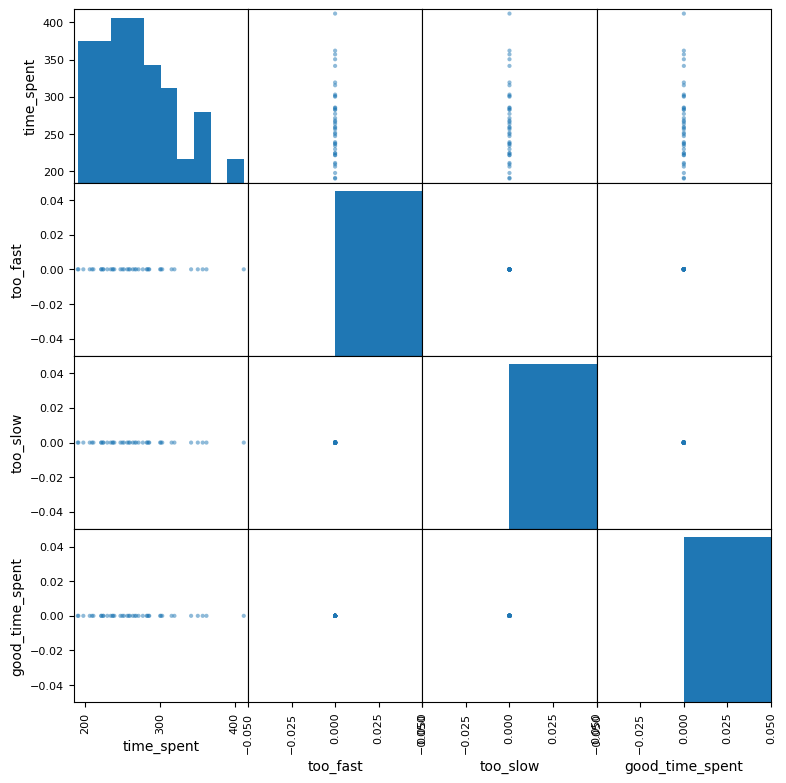

In [35]:
station_stat_multi = station_stat_multi.fillna(0)
pd.plotting.scatter_matrix(station_stat_multi, figsize=(9, 9))
